In [1]:
import pandas as pd
import sqlite3
import plotly.graph_objects as go
import plotly.express as px

# Connect to database
conn = sqlite3.connect("data/db/bluestock_mf.db")

# Load NAV data with fund names
query = """
SELECT n.nav_date, n.amfi_code, n.nav, f.scheme_name, f.fund_house
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
"""
nav_df = pd.read_sql_query(query, conn)
nav_df['nav_date'] = pd.to_datetime(nav_df['nav_date'])

print(f"Total rows: {nav_df.shape[0]}")
print(f"Date range: {nav_df['nav_date'].min()} to {nav_df['nav_date'].max()}")
print(f"Unique schemes: {nav_df['amfi_code'].nunique()}")
nav_df.head()

Total rows: 64320
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Unique schemes: 40


,nav_date,amfi_code,nav,scheme_name,fund_house
0,2022-01-03,100016,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,2022-01-04,100016,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
2,2022-01-05,100016,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
3,2022-01-06,100016,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
4,2022-01-07,100016,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund


In [2]:
# Plot NAV trend for all 40 schemes
fig = px.line(
    nav_df,
    x="nav_date",
    y="nav",
    color="scheme_name",
    title="NAV Trend Analysis - All 40 Schemes (2022-2026)",
    labels={"nav_date": "Date", "nav": "NAV (₹)"}
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run", annotation_position="top left",
    line_width=0
)

# Highlight 2024 market corrections
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction", annotation_position="top left",
    line_width=0
)

fig.update_layout(
    height=600,
    legend=dict(font=dict(size=8)),
    hovermode="x unified"
)

fig.show()

# Save as PNG for final report
fig.write_image("reports/nav_trend_chart.png", width=1400, height=700)
print("✅ Chart saved to reports/nav_trend_chart.png")  

✅ Chart saved to reports/nav_trend_chart.png


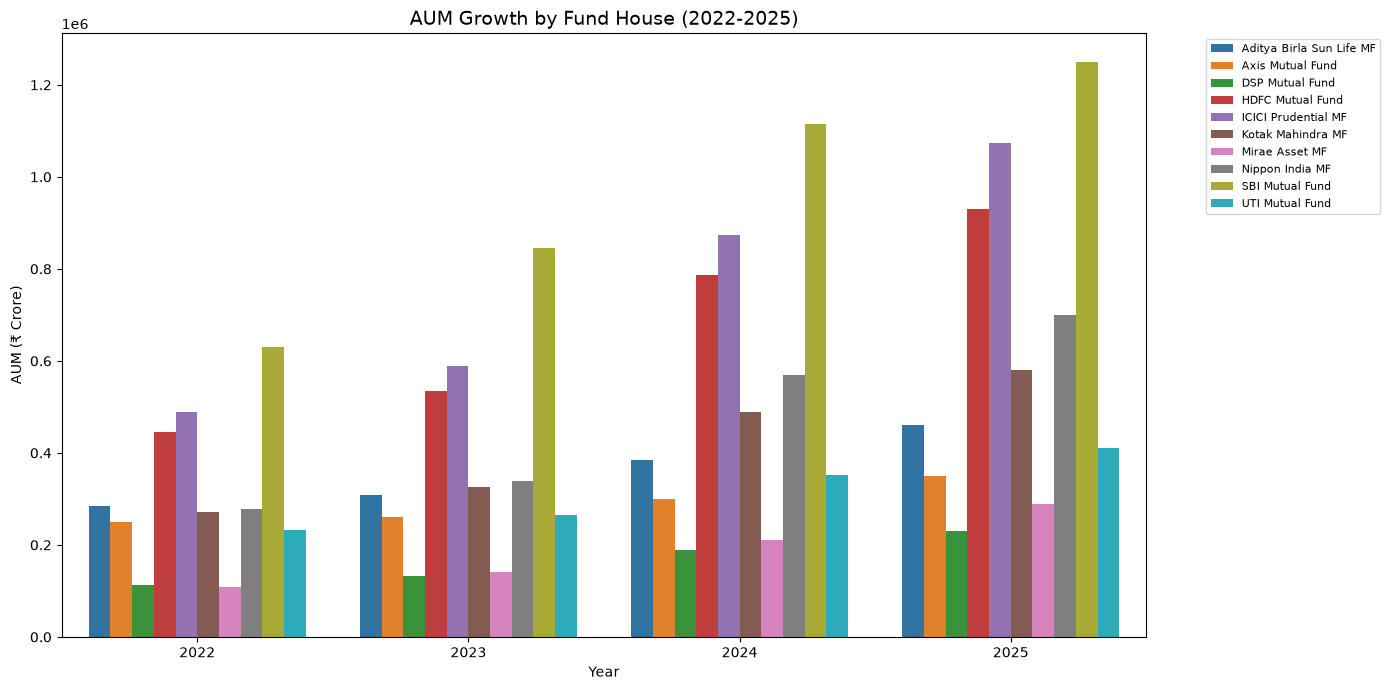

✅ Chart saved to reports/aum_growth_chart.png

Top fund houses by AUM (latest year):
             fund_house  year  aum_crore
35      SBI Mutual Fund  2025    1250000
19  ICICI Prudential MF  2025    1074000
15     HDFC Mutual Fund  2025     930000
31      Nippon India MF  2025     700000
23    Kotak Mahindra MF  2025     580000


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load AUM data
aum_query = "SELECT * FROM fact_aum"
aum_df = pd.read_sql_query(aum_query, conn)
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

# Aggregate AUM by fund_house and year (take year-end value)
aum_yearly = aum_df.groupby(['fund_house', 'year'])['aum_crore'].max().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=aum_yearly, x='year', y='aum_crore', hue='fund_house')
plt.title("AUM Growth by Fund House (2022-2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("reports/aum_growth_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/aum_growth_chart.png")

# Confirm SBI's dominance
top_aum = aum_yearly[aum_yearly['year'] == aum_yearly['year'].max()].sort_values('aum_crore', ascending=False)
print("\nTop fund houses by AUM (latest year):")
print(top_aum.head())

In [4]:
print(aum_df.columns.tolist())
print(aum_df.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [5]:
# Load SIP industry data
sip_query = "SELECT * FROM fact_sip_industry ORDER BY month"
sip_df = pd.read_sql_query(sip_query, conn)

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={"month": "Month", "sip_inflow_crore": "SIP Inflow (₹ Crore)"},
    markers=True
)

# Find and annotate the all-time high
max_row = sip_df.loc[sip_df['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"All-Time High: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="red", size=12),
    bgcolor="white"
)

fig.update_layout(height=550, hovermode="x unified")
fig.update_xaxes(tickangle=45)
fig.show()

fig.write_image("reports/sip_inflow_trend.png", width=1400, height=700)
print(f"✅ Chart saved. All-time high: ₹{max_row['sip_inflow_crore']:.0f} Cr in {max_row['month']}")

✅ Chart saved. All-time high: ₹31002 Cr in 2025-12


In [6]:
# Load category inflows data
cat_query = "SELECT * FROM fact_aum LIMIT 1"  # just to check connection
category_df = pd.read_sql_query("SELECT * FROM category_inflows", conn) if False else None

# Load directly from raw CSV since category_inflows isn't in DB yet
category_df = pd.read_csv("data/raw/05_category_inflows.csv")
print(category_df.columns.tolist())
print(category_df.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


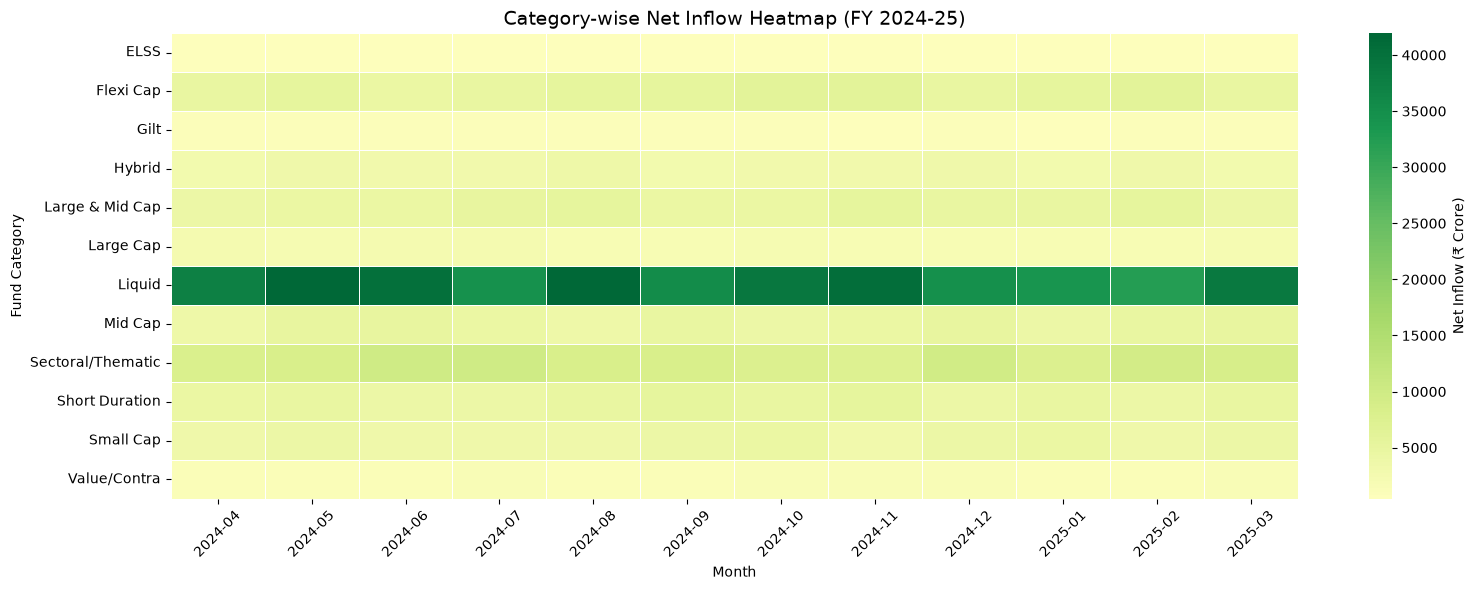

✅ Chart saved to reports/category_inflow_heatmap.png


In [7]:
# Load category inflows data
category_df = pd.read_csv("data/raw/05_category_inflows.csv")
print(category_df.columns.tolist())
print(category_df.head())

# Pivot for heatmap: months on X-axis, categories on Y-axis
pivot_df = category_df.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_df, cmap="RdYlGn", center=0, annot=False, linewidths=0.5, cbar_kws={'label': 'Net Inflow (₹ Crore)'})
plt.title("Category-wise Net Inflow Heatmap (FY 2024-25)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/category_inflow_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/category_inflow_heatmap.png")

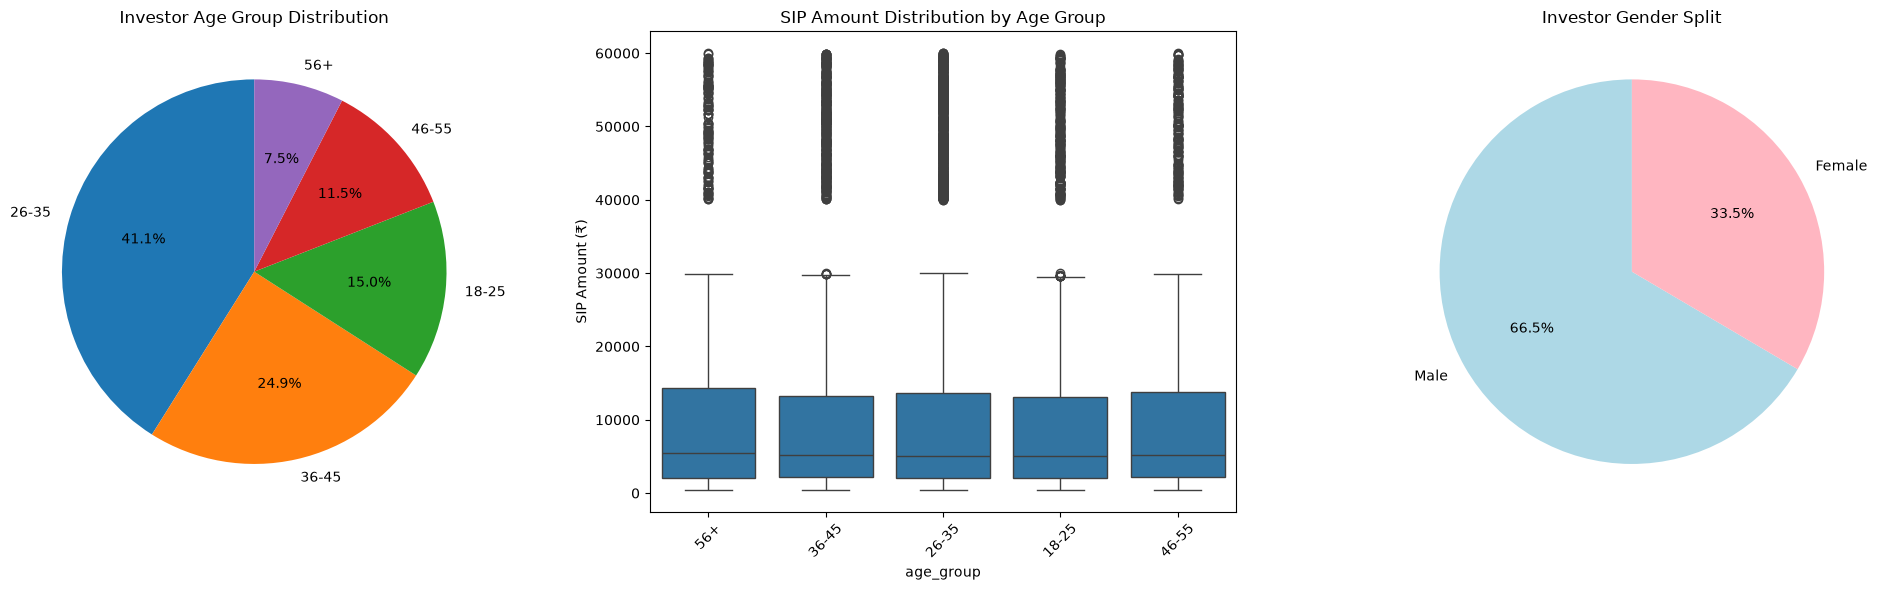

✅ Chart saved to reports/demographics_chart.png


In [8]:
# Load transactions data
txn_df = pd.read_csv("data/processed/clean_transactions.csv")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Age group distribution pie chart
age_counts = txn_df['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Investor Age Group Distribution")

# 2. SIP amount box plot by age group
sip_only = txn_df[txn_df['transaction_type'] == 'Sip']
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_ylabel("SIP Amount (₹)")
axes[1].tick_params(axis='x', rotation=45)

# 3. Gender split
gender_counts = txn_df['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightpink'])
axes[2].set_title("Investor Gender Split")

plt.tight_layout()
plt.savefig("reports/demographics_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/demographics_chart.png")

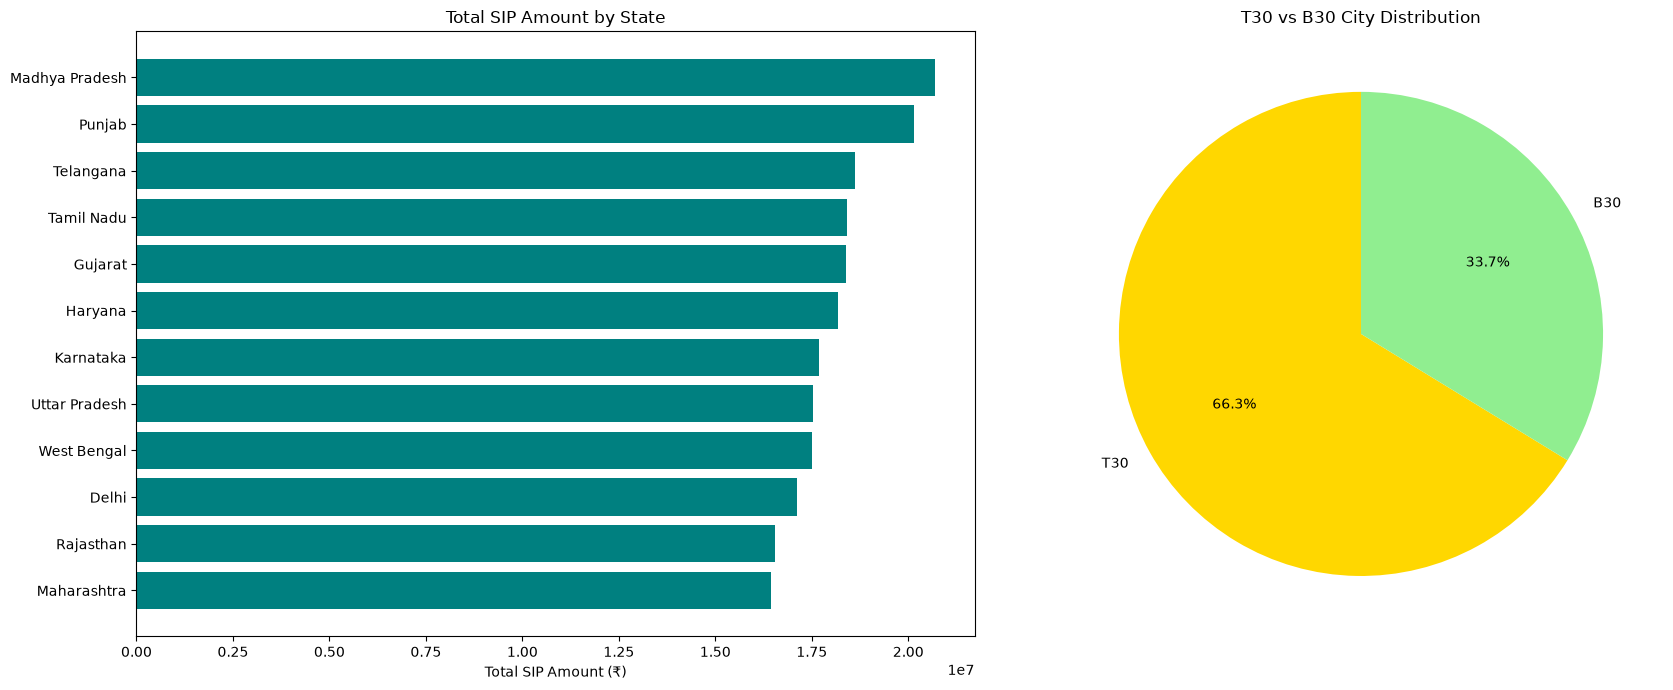

✅ Chart saved to reports/geo_distribution_chart.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Horizontal bar chart - SIP amount by state
state_sip = txn_df[txn_df['transaction_type'] == 'Sip'].groupby('state')['amount_inr'].sum().sort_values(ascending=True)
axes[0].barh(state_sip.index, state_sip.values, color='teal')
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("Total SIP Amount (₹)")

# 2. T30 vs B30 pie chart
tier_counts = txn_df['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightgreen'])
axes[1].set_title("T30 vs B30 City Distribution")

plt.tight_layout()
plt.savefig("reports/geo_distribution_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/geo_distribution_chart.png")

In [10]:
# Load folio count data
folio_df = pd.read_csv("data/raw/06_industry_folio_count.csv")
print(folio_df.columns.tolist())
print(folio_df.head())

# Auto-detect date and value columns
date_col = folio_df.columns[0]
value_cols = [c for c in folio_df.columns if 'folio' in c.lower() or 'crore' in c.lower()]

fig = px.line(
    folio_df,
    x=date_col,
    y=value_cols if value_cols else folio_df.columns[1],
    title="Mutual Fund Folio Count Growth (Jan 2022 - Dec 2025)",
    markers=True
)

# Mark milestones (start and end)
fig.add_annotation(
    x=folio_df[date_col].iloc[0],
    y=folio_df[value_cols[0]].iloc[0] if value_cols else folio_df.iloc[0, 1],
    text=f"Start: {folio_df.iloc[0, 1]} Cr",
    showarrow=True, arrowhead=2
)
fig.add_annotation(
    x=folio_df[date_col].iloc[-1],
    y=folio_df[value_cols[0]].iloc[-1] if value_cols else folio_df.iloc[-1, 1],
    text=f"End: {folio_df.iloc[-1, 1]} Cr",
    showarrow=True, arrowhead=2
)

fig.update_layout(height=550)
fig.show()

fig.write_image("reports/folio_growth_chart.png", width=1400, height=700)
print("✅ Chart saved to reports/folio_growth_chart.png")

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


✅ Chart saved to reports/folio_growth_chart.png


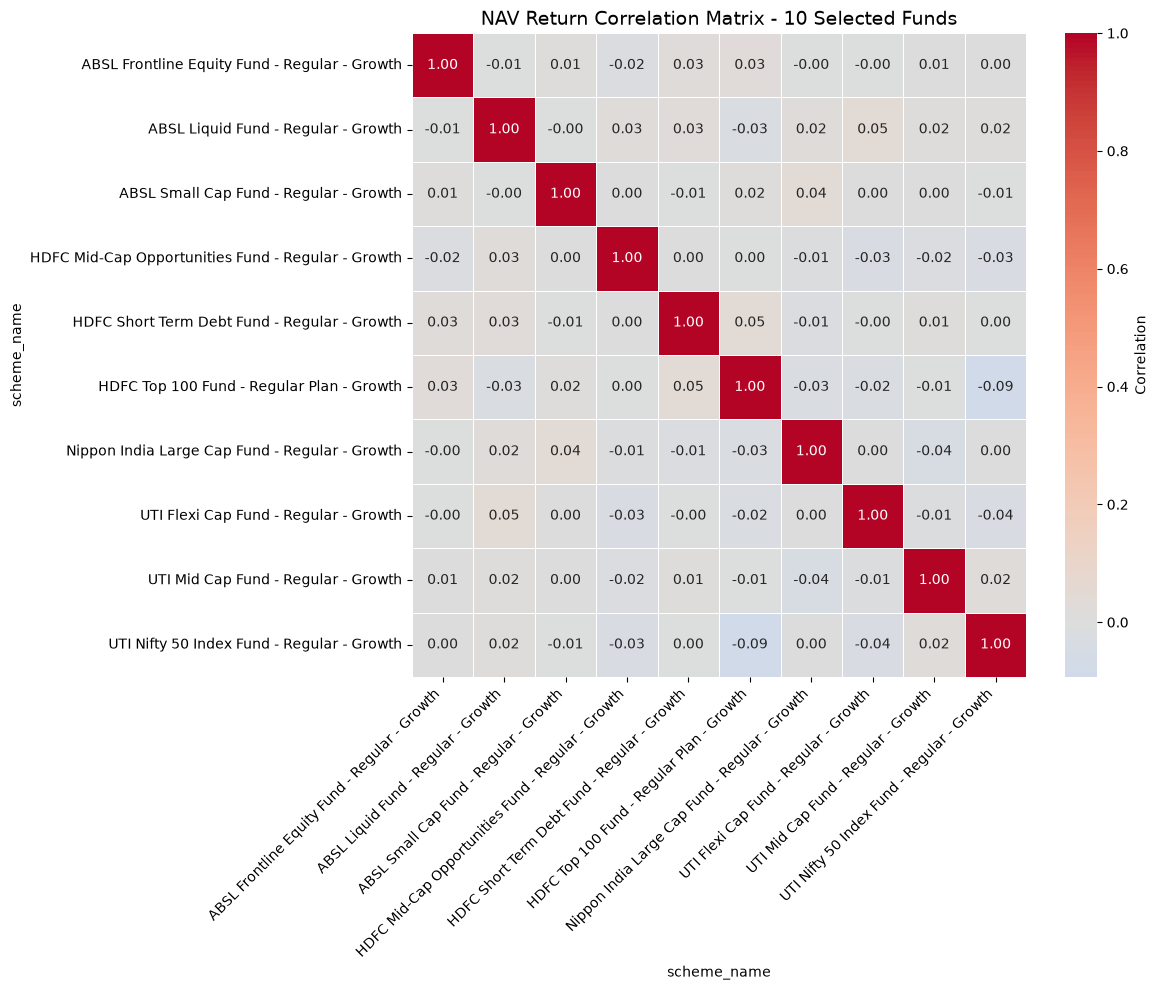

✅ Chart saved to reports/correlation_matrix.png


In [11]:
# Select 10 funds for correlation analysis
selected_codes = nav_df['amfi_code'].unique()[:10]

# Pivot NAV data: dates as rows, schemes as columns
nav_pivot = nav_df[nav_df['amfi_code'].isin(selected_codes)].pivot(
    index='nav_date', columns='scheme_name', values='nav'
)

# Compute daily returns
returns = nav_pivot.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title("NAV Return Correlation Matrix - 10 Selected Funds", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("reports/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/correlation_matrix.png")

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


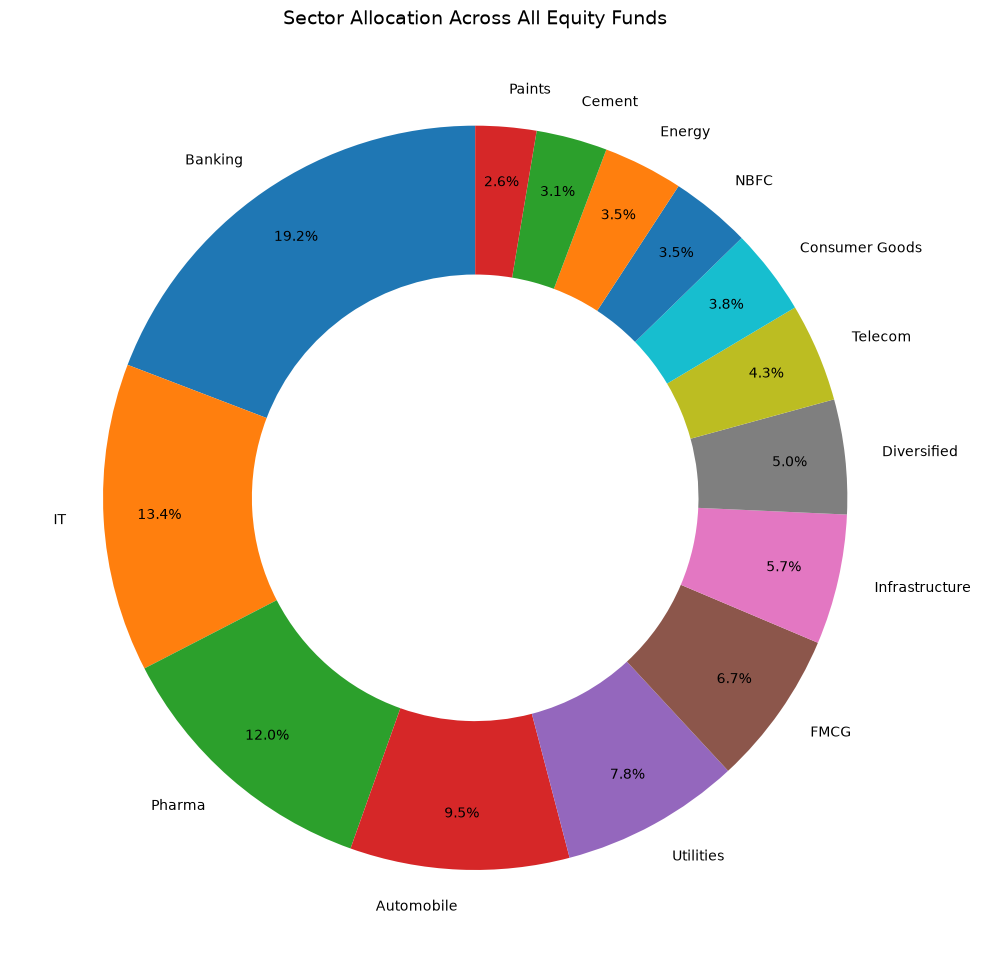

✅ Chart saved to reports/sector_allocation_donut.png


In [12]:
# Load portfolio holdings data
portfolio_df = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print(portfolio_df.columns.tolist())
print(portfolio_df.head())

# Aggregate sector weights across all equity funds
sector_weights = portfolio_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4)  # this creates the donut hole
)
ax.set_title("Sector Allocation Across All Equity Funds", fontsize=14)
plt.tight_layout()
plt.savefig("reports/sector_allocation_donut.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/sector_allocation_donut.png")

 Key EDA Findings — Bluestock MF Analytics

1. NAV Growth Trend:* Most schemes showed steady NAV growth from 2022-2026, with a clear bull run pattern visible in 2023 followed by a market correction phase in 2024. (See: NAV Trend Analysis chart)

2. SBI Mutual Fund Dominance:* SBI Mutual Fund consistently held the highest AUM among all fund houses across 2022-2025, reflecting its market leadership position. (See: AUM Growth Bar Chart)

3. Record SIP Inflows:* Monthly SIP inflows showed a strong upward trend, peaking at an all-time high in late 2025, reflecting growing retail investor participation via systematic investing. (See: SIP Inflow Time-Series chart)

4. Liquid Funds Lead Category Inflows:* The Liquid fund category consistently attracted the highest net inflows compared to other categories like Large Cap, Mid Cap, and ELSS throughout FY 2024-25. (See: Category Inflow Heatmap)

5. Investor Demographics Skew:* The majority of investors fall within the 26-45 age bracket, with SIP amounts varying significantly by age group — older investors tend to invest larger SIP amounts on average. (See: Investor Demographics charts)

6. Geographic Concentration:* SIP investments are heavily concentrated in a handful of states, with metro/Tier-1 cities (T30) contributing a disproportionately larger share of total SIP amount compared to B30 (Beyond Top 30) cities. (See: Geographic Distribution chart)

7. Exponential Folio Growth:* Total mutual fund folio count nearly doubled from 13.26 crore (Jan 2022) to over 26 crore (by 2025-26), highlighting rapid retail adoption of mutual funds in India. (See: Folio Count Growth chart)

8. Low Correlation Among Select Funds:* The correlation matrix of daily returns across 10 selected schemes shows that funds across different categories (e.g., equity vs liquid) have low to negative correlation, useful for diversification. (See: NAV Return Correlation Matrix)

9. Sector Concentration in Equity Portfolios:* Aggregated sector allocation data shows a concentration in a few key sectors (e.g., Financial Services, IT, Energy), indicating potential sector-specific risk across equity mutual fund portfolios. (See: Sector Allocation Donut Chart)

10. Data Quality is Strong:* Across all 10 datasets, AMFI code validation confirmed 100% consistency between fund_master and nav_history with zero missing or mismatched codes, indicating reliable data foundation for further analysis. (See: Day 1 validation report)